In [1]:
"""Demo script running a QPE simulation from the Python interface."""

from math import cos, pi

from qualtran.drawing import show_bloq

from quiche import hamlib
from quiche.bindings.quest_bindings import QuESTEnv, Qureg
from quiche.chemistry import HartreeFockState
from quiche.core import (
    ElectronicHamiltonian,
    Errors,
    Mapping,
    PhaseEstimation,
    Simulation,
)
from quiche.dispatch import QPESpec
from quiche.resources.logical import logical_gate_resources, logical_qubit_resources

In [2]:
hdf5_path = "H2.hdf5"
dataset = "ham_JW-4"
num_electrons = 2
num_qubits = 4

# Retrieve and parse Hamlib Hamiltonian
raw_data = hamlib.get_dataset(str(hdf5_path), dataset)
quiche_sum = hamlib.parse_hamiltonian(raw_data)

ham = ElectronicHamiltonian(
    electrons=num_electrons,
    paulis=quiche_sum,
    mapping=Mapping.JordanWigner,
)

eps = 0.5
error = Errors(
    estimation=eps,
    simulation=eps,
    rotations=eps,
    state_prep=eps,
    overlap=eps,
)

hf = HartreeFockState.closed_shell(electrons=num_electrons, spin_orbitals=num_qubits)

qpe_spec = QPESpec(
    hamiltonian=ham,
    state_prep=hf,
    algorithm=PhaseEstimation.Textbook,
    simulation=Simulation.Qubitised,
    error_budget=error,
)

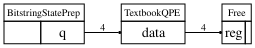

In [3]:
bloq = qpe_spec.get_composite_bloq()
show_bloq(bloq)

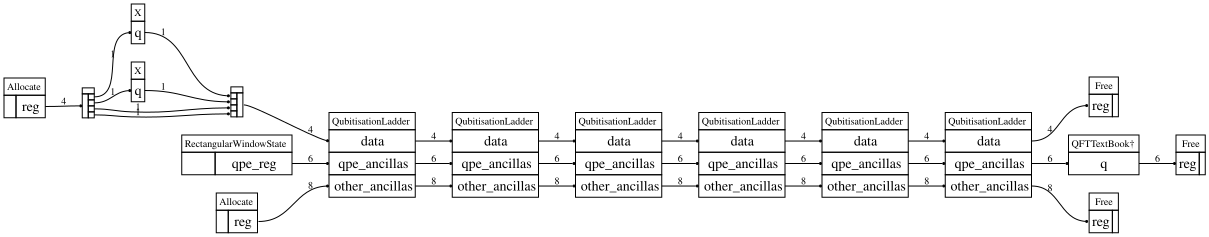

In [4]:
flat = bloq.flatten_once()
show_bloq(flat)

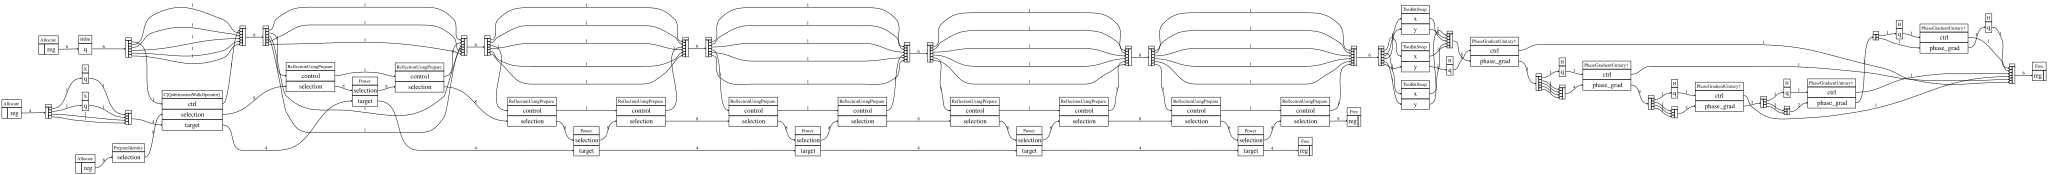

In [5]:
flat = flat.flatten_once()
show_bloq(flat)

In [6]:
print("Qubit count:", logical_qubit_resources(flat))
print("Logical resources:", logical_gate_resources(flat))

Qubit count: 27
Logical resources: t: 4, toffoli: 640, and_bloq: 3446, clifford: 15058, rotation: 6, measurement: 3446


In [7]:
qpe_spec = QPESpec(
    hamiltonian=ham,
    state_prep=hf,
    algorithm=PhaseEstimation.Kitaev,
    simulation=Simulation.Trotter,
    error_budget=error,
)

print("INFO: Generating QuEST circuit.")
quest_routine = qpe_spec.to_quest()

print("INFO: Running QuEST simulation.")
with QuESTEnv():
    qureg = Qureg(qpe_spec.num_qubits)
    results = quest_routine.evaluate(qureg)

phase = results[-1]

if qpe_spec.simulation == Simulation.Qubitised:
    energy = cos(phase * 2 * pi) * quiche_sum.lam + quiche_sum.identity_coefficient
else:
    energy = phase * (2 * pi / qpe_spec.time) + quiche_sum.identity_coefficient

print("-" * 30, "Results", "-" * 30)
print(f"Phase: {phase:.5f}")
print(f"Energy: {energy:.5f}")

INFO: Generating QuEST circuit.
INFO: Running QuEST simulation.
------------------------------ Results ------------------------------
Phase: -0.28125
Energy: -1.14172
